# Libraries

In [37]:
import numpy as np
import scipy
from scipy import signal, fft
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

root = str(Path().resolve().parent)
if root not in sys.path:
    sys.path.append(root)
print(*sys.path, sep="\n")

# %matplotlib ipympl
%matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/rfdsp_sim/python/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/rfdsp_sim/python


In [72]:
from importlib import reload
from rfdsppy import calc, ofdm, rf_analog, rf_tx_fw, tonegen, digital_filter_design, digital_hw_algo as dighw, rf_estimation as rf_est, single_carrier as sc

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)
reload(sc)

<module 'rfdsppy.single_carrier' from '/home/ryanwtsai/repos/rfdsp_sim/python/rfdsppy/single_carrier.py'>

# Single-carrier waveform generation

EVM: 12.378984068394654 %
SNR: 18.146299919879706 dB


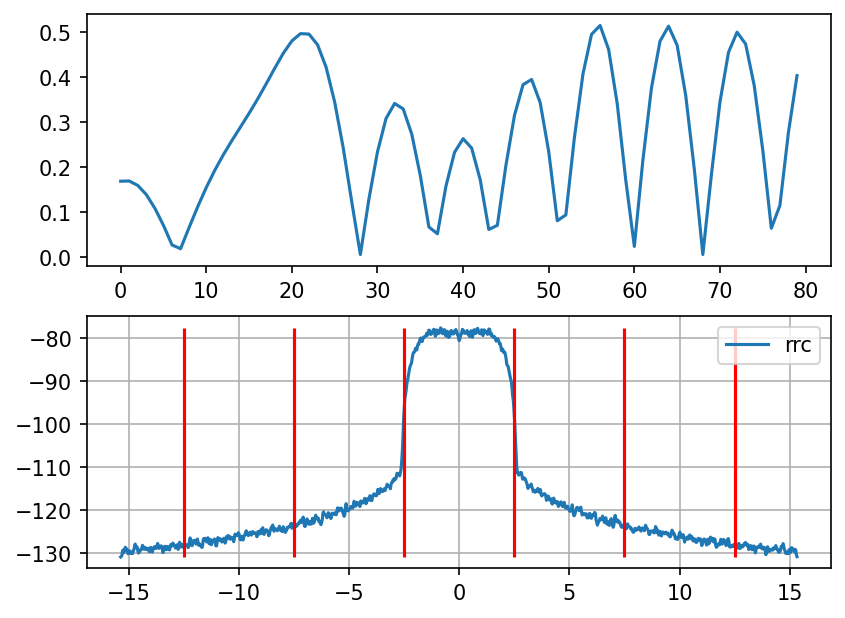

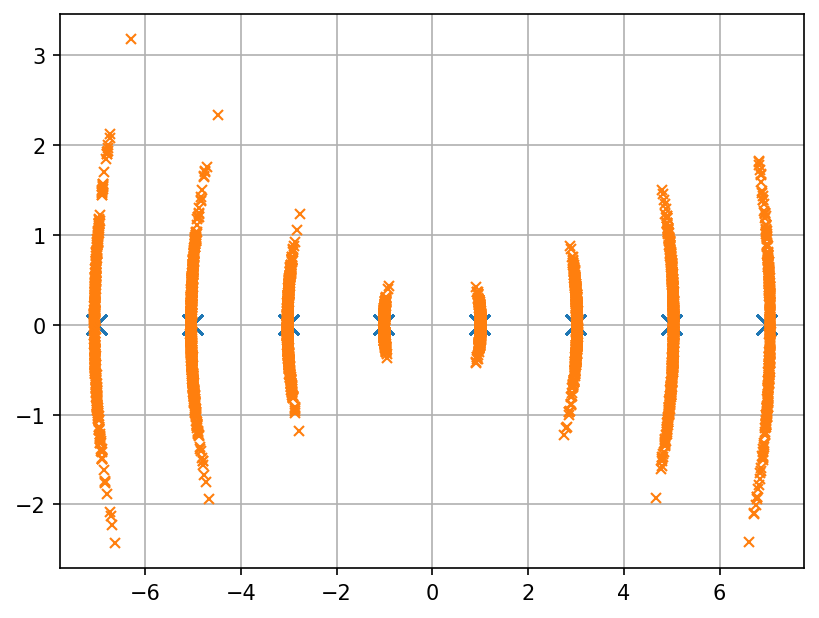

In [75]:
pulse_shapes = ["rectangular", "triangular", "sawtooth", "hann"]
pulse_shapes = ["rectangular", "rc", "rrc"]
pulse_shapes = ["rrc"]
mod = ("PSK", 4)
mod = ("ASK", 8)
# mod = "ASK"
# mod = "FSK"
fig, axs = plt.subplots(nrows=2, dpi=150)
awgn = rf_analog.AWGN(-20, 3.84, 30.72)
for pulse_shape in pulse_shapes:
    wg = sc.SCWavGen(pulse_shape=pulse_shape, modulation=mod, power=0)

    x = wg.generate(4000)
    cfg = wg.get_demod_params()
    fs = cfg.get("fs")
    gd = cfg.get("gd")
    # x_awgn = awgn.transform(x)
    pn = rf_analog.PhaseNoise(-70, -150, 100/1000, 1/1000, fs)
    x_awgn = pn.transform(x)
    # x_awgn = x

    p, f = rf_est.sde(x_awgn, fs, fs/1024)
    p_dbm = 10*np.log10(p)
    
    axs[0].plot(np.abs(x_awgn[math.floor(gd):math.floor(gd)+8*10]), label=pulse_shape)
        
    axs[1].plot(f, p_dbm, label=pulse_shape)

axs[1].vlines([-12.5, -7.5, -2.5, 2.5, 7.5, 12.5], ymin=p_dbm.min(), ymax=p_dbm.max(), colors="r")
axs[1].grid()
axs[1].legend()

y_sampled = wg.matched_filter_and_sample(x_awgn, gd)

evm = wg.calculate_evm(y_sampled)
print(f"EVM: {evm} %")
print(f"SNR: {-20*np.log10(evm/100)} dB")

In [ ]:
# y_raw = signal.lfilter(wg.b_[::-1], 1, x)
# y_sampled = y_raw[round(gd+wg.gd_)::wg.osr]



In [59]:
calc.rms(pn.theta_)

np.float64(0.12696735002123435)

EVM: 12.421726713177284 %
SNR: 18.1163605954572 dB


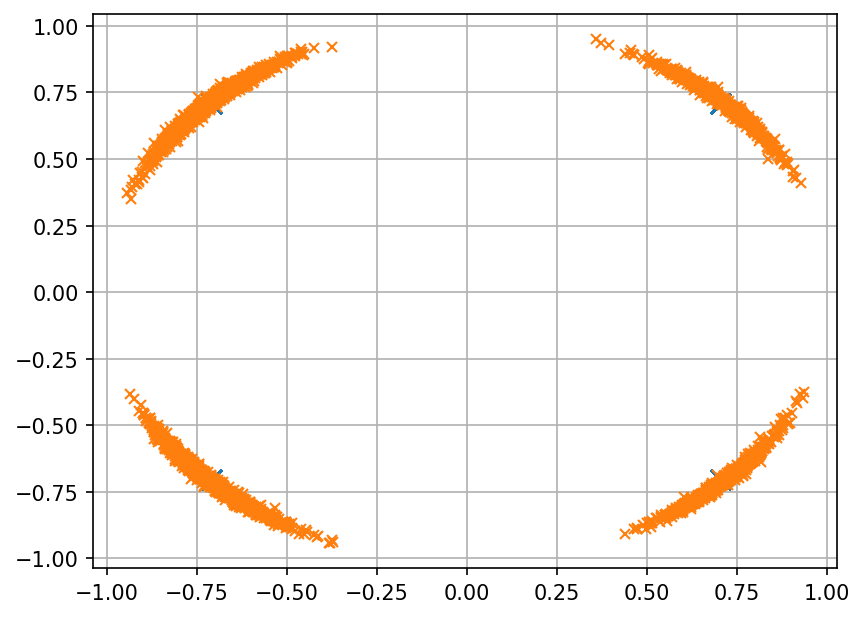

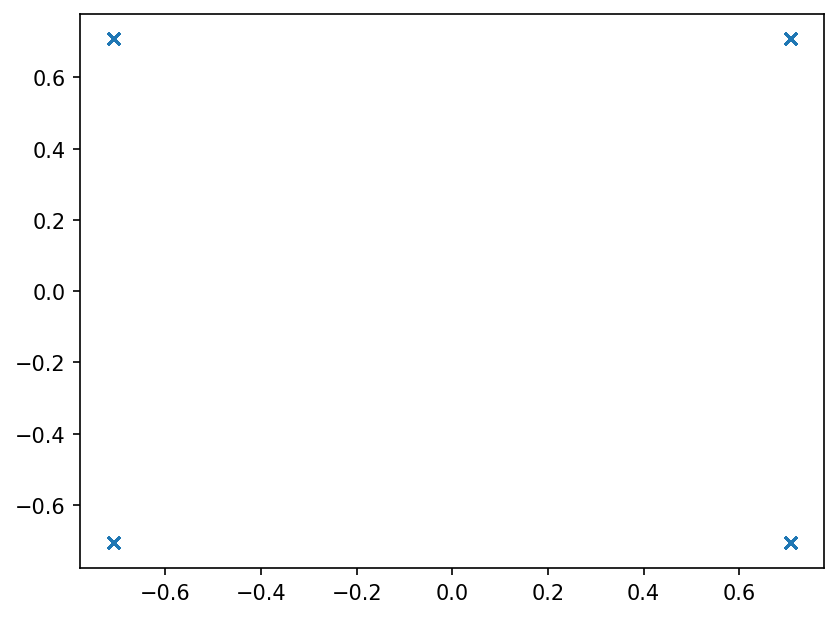

In [50]:
fig, ax = plt.subplots(dpi=150)

ax.plot(wg.symbols_.real, wg.symbols_.imag, 'x')

(80.0, 220.0)

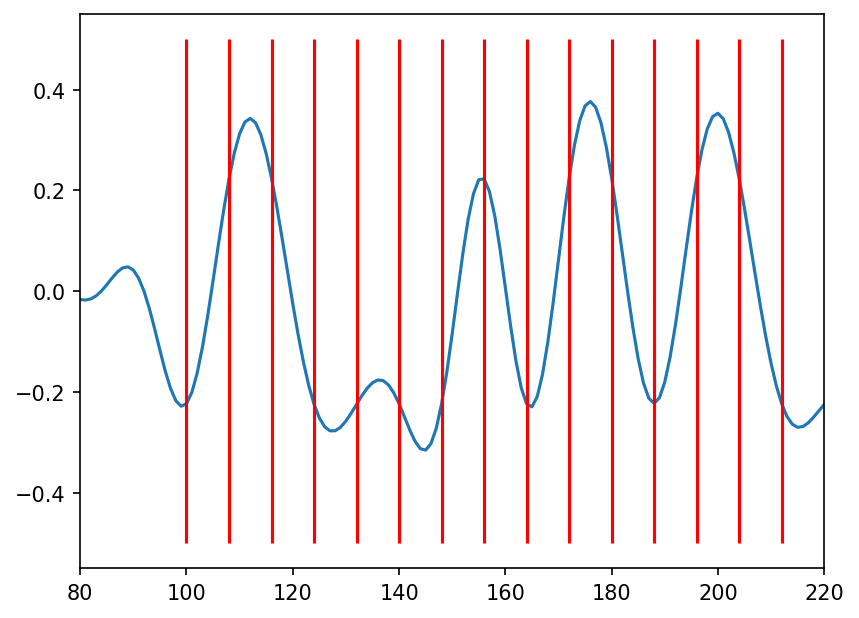

In [ ]:
fig, ax = plt.subplots(dpi=150)
ax.plot(y_raw)
ax.vlines([np.arange(round(gd+wg.gd_), round(gd+wg.gd_)+8*15, 8)], ymin=-0.5, ymax=0.5, colors="r")
ax.set_xlim(left=round(gd+wg.gd_)-20, right=round(gd+wg.gd_)+8*15)

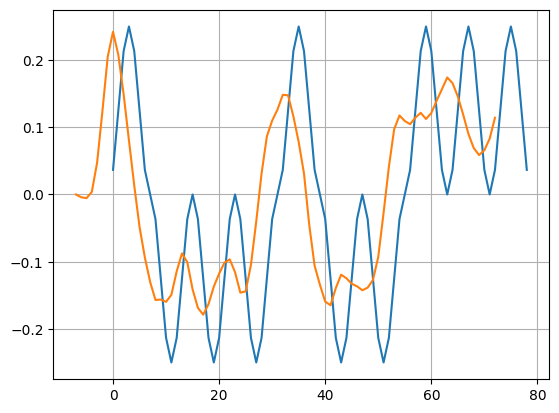

In [22]:
# corr = signal.correlate(x, wg.b_[::-1])
# lags = signal.correlation_lags(x.size, wg.b_.size)
# corr = signal.correlate(np.diff(np.angle(x)), wg.b_[::-1])
corr = signal.correlate(np.diff(np.angle(x_awgn)), wg.b_[::-1])
lags = signal.correlation_lags(x.size-1, wg.b_.size)

fig, ax = plt.subplots(dpi=100)
max_sample = 8*10
# max_sample = -1
ax.plot(np.diff(np.angle(x[:max_sample])))
# ax.plot(x_awgn[:max_sample])
ax.plot(lags[:max_sample], corr[:max_sample])
ax.grid()

# y = x_awgn*np.exp(1j*20*2*np.pi/fs*np.arange(x.size, dtype="float"))
# y = x_awgn
# corr = signal.correlate(y, y)
# fig, ax = plt.subplots(dpi=100)
# p, f = rf_est.sde(y, fs, fs/1024)
# p_dbm = 10*np.log10(p)
# ax.plot(f, p_dbm)
# p, f = rf_est.sde(corr, fs, fs/1024)
# p_dbm = 10*np.log10(p)
# ax.plot(f, p_dbm)

In [ ]:
numtaps = 101
beta = 0.35
osr = 8

t = np.arange(-math.floor(numtaps/2), numtaps-math.floor(numtaps/2), dtype="float")/osr

h = np.sin(np.pi*t)/(np.pi*t)*np.cos(np.pi*beta*t)/(1-(2*beta*t)**2)
h[t == 0] = 1

fig, ax = plt.subplots(dpi=100)

ax.plot(h)

In [129]:
numtaps = 101
beta = 0.35
osr = 8

t = np.arange(-math.floor(numtaps/2), numtaps-math.floor(numtaps/2), dtype="float")

h = np.sin(np.pi*t/osr)/(np.pi*t/osr)*np.cos(np.pi*beta*t/osr)/(1-(2*beta*t/osr)**2)
h[t == 0] = 1
h_rc = h/osr

# fig, ax = plt.subplots(dpi=100)

# ax.plot(h)

/tmp/ipykernel_163002/3562098642.py:7: RuntimeWarning: invalid value encountered in divide
  h = np.sin(np.pi*t/osr)/(np.pi*t/osr)*np.cos(np.pi*beta*t/osr)/(1-(2*beta*t/osr)**2)


In [110]:
h_rc[49:52]

array([0.12159411, 0.125     , 0.12159411])

/tmp/ipykernel_163002/517461771.py:7: RuntimeWarning: invalid value encountered in divide
  h = 1/osr*(np.sin(np.pi*t/osr*(1-beta)) + 4*beta*t/osr*np.cos(np.pi*t/osr*(1+beta)))/(np.pi*t/osr*(1-(4*beta*t/osr)**2))


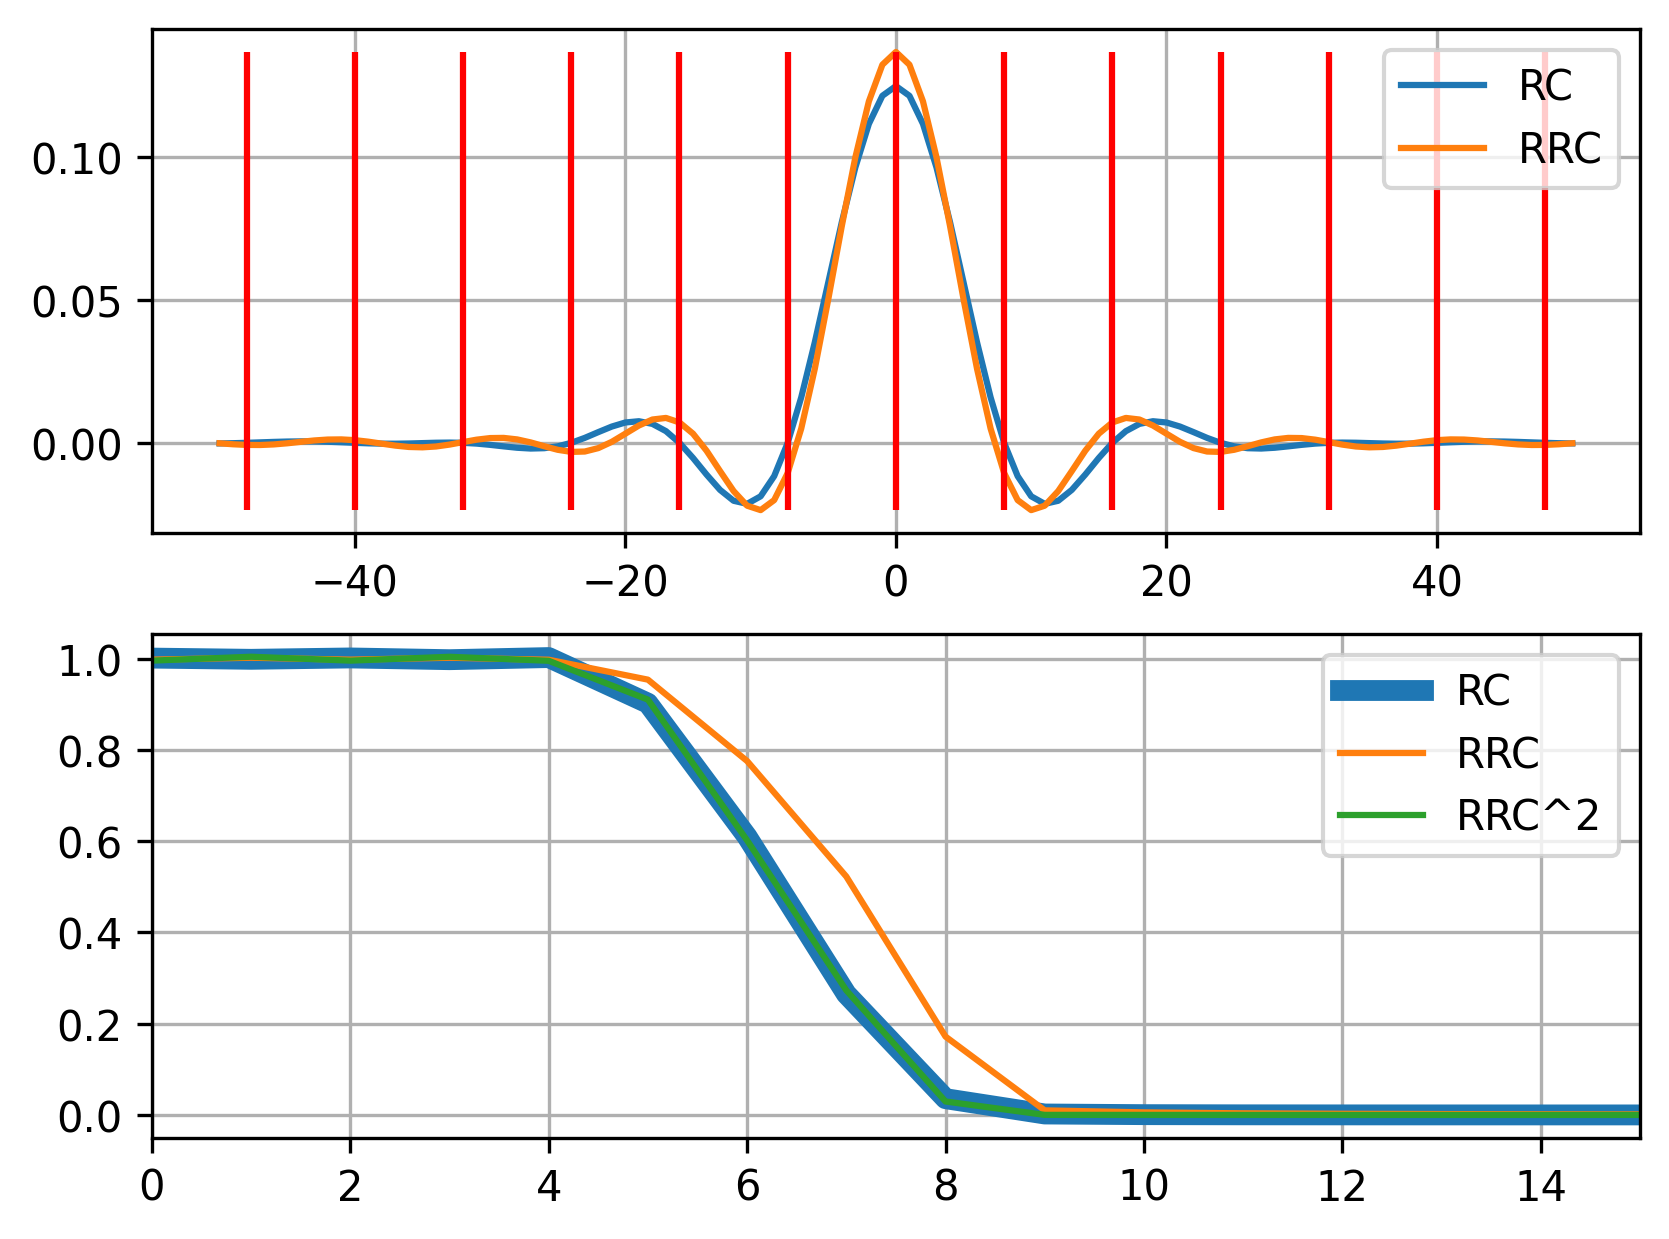

In [103]:
numtaps = 101
beta = 0.35
osr = 8

t = np.arange(-math.floor(numtaps/2), numtaps-math.floor(numtaps/2), dtype="float")

h = 1/osr*(np.sin(np.pi*t/osr*(1-beta)) + 4*beta*t/osr*np.cos(np.pi*t/osr*(1+beta)))/(np.pi*t/osr*(1-(4*beta*t/osr)**2))
h[t == 0] = 1/osr*(1+beta*(4/np.pi-1))
h[t == osr/4/beta] = beta/osr/np.sqrt(2)*((1+2/np.pi)*np.sin(np.pi/4/beta) + (1-2/np.pi)*np.cos(np.pi/4/beta))
h[t == -osr/4/beta] = beta/osr/np.sqrt(2)*((1+2/np.pi)*np.sin(np.pi/4/beta) + (1-2/np.pi)*np.cos(np.pi/4/beta))
h_rrc = h

fig, ax = plt.subplots(nrows=2, dpi=300)

ax[0].plot(t, h_rc, label="RC")
ax[0].plot(t, h_rrc, label="RRC")
ax[0].vlines(np.arange(-6, 7)*8, ymin=h_rrc.min(), ymax=h_rrc.max(), colors="r")
ax[0].legend()
ax[0].grid()

fft_rc = fft.fft(h_rc)
fft_rrc = fft.fft(h_rrc)
ax[1].plot(np.abs(fft_rc), linewidth=5, label="RC")
ax[1].plot(np.abs(fft_rrc), label="RRC")
ax[1].plot(np.abs(fft_rrc**2), label="RRC^2")
ax[1].set_xlim(left=0, right=15)
ax[1].legend()
ax[1].grid()

285.0
9


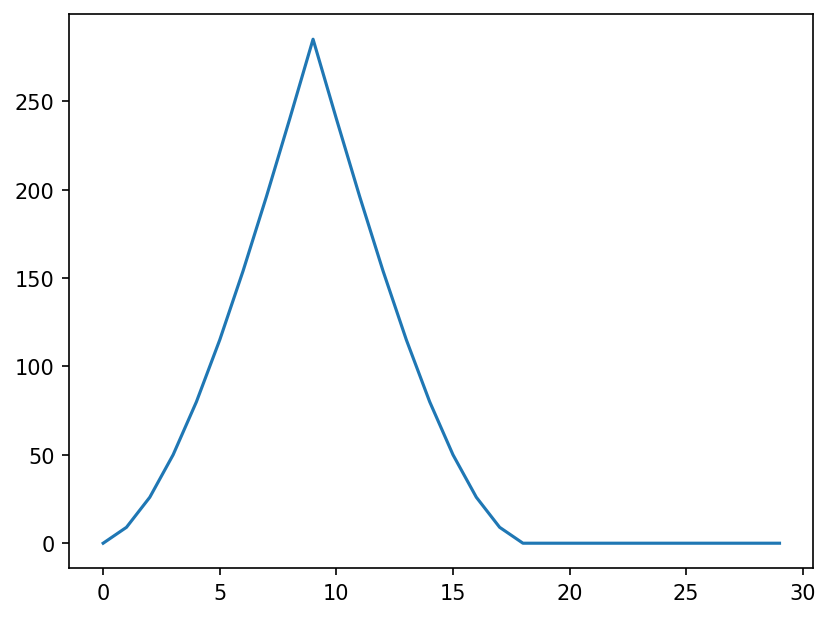

In [102]:
x = np.arange(10, dtype="float")
c = signal.convolve(x, x[::-1])

c = signal.lfilter(x[::-1], 1, np.concatenate((x, np.zeros(20))))
print(c.max())
print(c.argmax())

fig, ax = plt.subplots(dpi=150)
ax.plot(c)

In [13]:
rng = np.random.default_rng()
M = 2

symb = np.round(rng.uniform(low=0, high=1, size=4096)*(M-1))*2-(M-1) + 1j*np.zeros(4096)

np.unique(symb)

array([-1.+0.j,  1.+0.j])

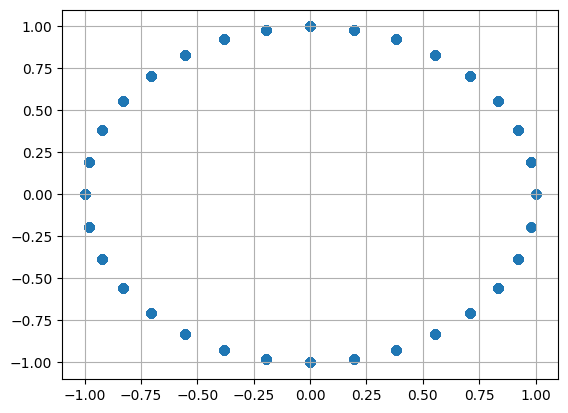

In [36]:
M = 32

symb = np.exp(1j*2*np.pi*(np.round(rng.uniform(low=1, high=M, size=4096))-1)/M)

if M == 4:
    symb = symb*np.exp(1j*np.pi/4)
if M == 2:
    symb = symb.real + 1j*np.zeros(symb.size)

fig, ax = plt.subplots(dpi=100)

ax.scatter(symb.real, symb.imag)
ax.grid()

In [27]:
np.unique(symb)

array([-1.+1.2246468e-16j,  1.+0.0000000e+00j])